# Chapter 2 — Data and Sampling Distributions

**Book:** Practical Statistics for Data Scientists, 2nd Edition  
**Name :** Rainaldi Pakpahan  
**NIM:** 101032300084  
**Class:** TK 47-04  

## Tujuan

Chapter ini membahas bagaimana sample digunakan untuk memahami
population, bagaimana sampling menghasilkan variasi statistik,
serta bagaimana bootstrap dan confidence interval digunakan untuk
mengukur ketidakpastian hasil analisis.

## Alur Pembahasan

1. Menyiapkan dataset
2. Population dan sample
3. Random sampling
4. Sampling bias
5. Sampling distribution
6. Standard error
7. Bootstrap
8. Confidence interval
9. Normal distribution
10. Long-tailed dan t-distribution
11. Binomial distribution
12. Poisson distribution
13. Kesimpulan

In [15]:
%pip -q install wquantiles

In [16]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)

print("Library berhasil dimuat.")

Library berhasil dimuat.


### Interpretasi

Library berhasil dimuat dan siap digunakan untuk simulasi sampling,
perhitungan statistik, serta visualisasi distribusi.

## 1. Menyiapkan Dataset

Pada chapter ini digunakan data income sebagai contoh untuk memahami
perbedaan antara population, sample, dan sampling distribution.

In [17]:
REPO_DIR = Path("/content/practical-statistics-for-data-scientists")
REPO_URL = "https://github.com/gedeck/practical-statistics-for-data-scientists.git"

if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
        check=True
    )

DATA_DIR = REPO_DIR / "data"

print("Dataset berada di:")
print(DATA_DIR)

Dataset berada di:
/content/practical-statistics-for-data-scientists/data


In [18]:
income = pd.read_csv(
    DATA_DIR / "loans_income.csv"
).squeeze("columns")

income.name = "Income"

print("Jumlah data:", len(income))
income.head()

Jumlah data: 50000


,Income
0,67000
1,52000
2,100000
3,78762
4,37041


### Interpretasi

Dataset income berisi banyak observasi yang dapat digunakan sebagai
population untuk melakukan simulasi pengambilan sample.

## 2. Mengenali Data Population

Population merupakan seluruh data yang menjadi objek analisis.
Sebelum mengambil sample, distribusi population perlu dilihat terlebih
dahulu.

In [19]:
print(income.describe())

count    50,000.000
mean     68,760.518
std      32,872.035
min       4,000.000
25%      45,000.000
50%      62,000.000
75%      85,000.000
max     199,000.000
Name: Income, dtype: float64


### Interpretasi

Dataset income memiliki 50.000 observasi dengan rata-rata pendapatan
sebesar 68,760.518 dan median 62,000. Nilai maksimum mencapai
199,000, sedangkan minimum 4,000, sehingga data memiliki rentang yang
cukup besar dan cenderung menceng ke kanan.

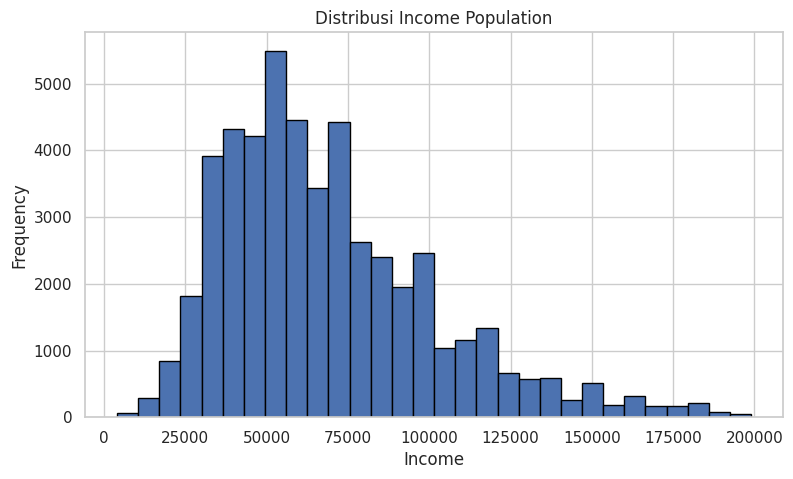

In [20]:
plt.figure(figsize=(9, 5))

plt.hist(
    income,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Distribusi Income Population")

plt.show()

### Interpretasi

Histogram menunjukkan bahwa nilai income tersebar pada beberapa
rentang, dengan sebagian besar observasi terkonsentrasi pada rentang
pendapatan tertentu.

## 3. Population dan Sample

Population adalah keseluruhan data, sedangkan sample merupakan sebagian
data yang diambil dari population. Sample digunakan ketika menganalisis
seluruh population tidak praktis atau tidak diperlukan.

In [21]:
rng = np.random.default_rng(42)

sample = rng.choice(
    income,
    size=100,
    replace=False
)

print("Ukuran population :", len(income))
print("Ukuran sample     :", len(sample))

Ukuran population : 50000
Ukuran sample     : 100


### Interpretasi

Population terdiri dari 50.000 observasi, sedangkan sample hanya
menggunakan 100 observasi yang dipilih secara acak. Sample digunakan
sebagai sebagian representasi dari population dalam proses analisis.

In [22]:
population_mean = income.mean()
sample_mean = sample.mean()

print(f"Population mean : {population_mean:,.2f}")
print(f"Sample mean     : {sample_mean:,.2f}")
print(f"Selisih         : {sample_mean - population_mean:,.2f}")

Population mean : 68,760.52
Sample mean     : 72,578.86
Selisih         : 3,818.34


### Interpretasi

Sample mean sebesar 72,578.86 sedikit lebih tinggi dibandingkan
population mean sebesar 68,760.52. Selisih sebesar 3,818.34
menunjukkan adanya variasi sampling karena sample hanya mengambil
sebagian dari population.

## 4. Random Sampling

Random sampling memberikan kesempatan kepada anggota population untuk
dipilih secara acak. Metode ini membantu mengurangi risiko sample
terbentuk dari pilihan yang terlalu berpihak pada kelompok tertentu.

In [23]:
samples = {}

for size in [20, 50, 100]:
    samples[size] = rng.choice(
        income,
        size=size,
        replace=False
    )

sample_means = {
    size: values.mean()
    for size, values in samples.items()
}

sample_means

{20: np.float64(67157.25), 50: np.float64(69563.86), 100: np.float64(64911.25)}

### Interpretasi

Rata-rata sample berbeda-beda untuk ukuran 20, 50, dan 100 karena
setiap sample berisi data acak yang berbeda. Perbedaan ini menunjukkan
adanya variasi dalam proses sampling.

## 5. Sampling Bias

Sampling bias terjadi ketika cara memilih sample menyebabkan sample
tidak mewakili population secara baik. Sample yang besar belum tentu
bebas dari bias apabila metode pemilihannya tidak tepat.

### Interpretasi

Kualitas sample tidak hanya ditentukan oleh jumlah data. Cara sample
dipilih juga menentukan apakah hasilnya dapat menggambarkan
population dengan baik.

## 6. Sampling Distribution

Sampling distribution adalah distribusi dari suatu statistik yang
dihasilkan dari banyak sample yang diambil dari population yang sama.
Pada bagian ini kita menggunakan sample mean sebagai statistik yang
diamati.

In [24]:
rng = np.random.default_rng(42)

sample_size = 50
number_of_samples = 1000

sample_means = np.array([
    rng.choice(
        income,
        size=sample_size,
        replace=False
    ).mean()
    for _ in range(number_of_samples)
])

print("Jumlah sample:", len(sample_means))
print("Mean sampling distribution:", sample_means.mean())

Jumlah sample: 1000
Mean sampling distribution: 68654.39196000001


### Interpretasi

Dari 1000 sample dengan ukuran 50, diperoleh mean sampling distribution
sekitar 68,654.39. Nilai ini dekat dengan population mean sehingga
sample mean cenderung berpusat di sekitar rata-rata population.

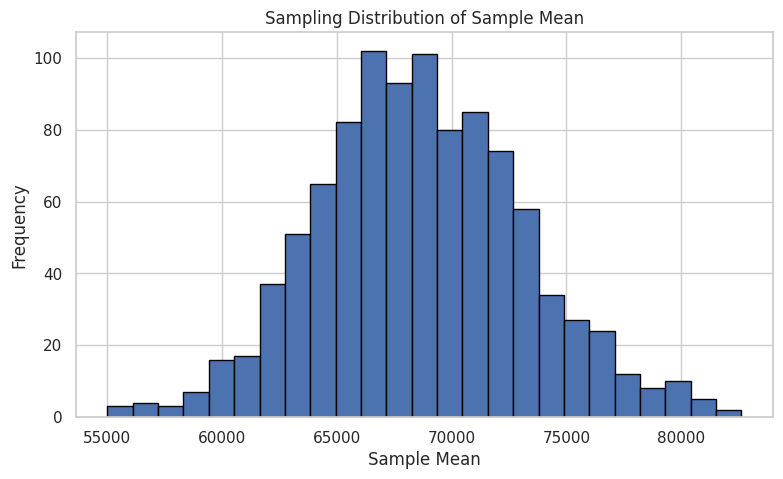

In [25]:
plt.figure(figsize=(9, 5))

plt.hist(
    sample_means,
    bins=25,
    edgecolor="black"
)

plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of Sample Mean")

plt.show()

### Interpretasi

Histogram menunjukkan distribusi sample mean yang membentuk pola
mendekati lonceng dan terkonsentrasi di sekitar nilai tengah.
Hal ini menunjukkan bahwa hasil sample mean dari banyak pengambilan
sample cenderung stabil di sekitar population mean.

## 7. Standard Error

Standard error menunjukkan seberapa besar variasi suatu statistik
sample dari satu sample ke sample lainnya. Untuk sample mean,
standard error dapat dihitung dengan:

SE = s / √n

In [26]:
sample_sizes = [10, 30, 100, 300]

se_results = []

for size in sample_sizes:
    means = np.array([
        rng.choice(
            income,
            size=size,
            replace=False
        ).mean()
        for _ in range(500)
    ])

    se_results.append({
        "Sample Size": size,
        "Standard Error": means.std(ddof=1)
    })

se_table = pd.DataFrame(se_results)

se_table

,Sample Size,Standard Error
0,10,"10,322.412"
1,30,"5,841.930"
2,100,"3,233.434"
3,300,"1,813.204"


### Interpretasi

Standard error semakin kecil ketika ukuran sample bertambah.
Hal ini menunjukkan bahwa sample yang lebih besar menghasilkan
estimasi mean yang lebih stabil.

## 8. Bootstrap

Bootstrap adalah metode resampling dengan mengambil sample berulang
kali dari data asli dengan pengembalian. Metode ini digunakan untuk
memperkirakan variasi suatu statistik, seperti mean.

In [27]:
rng = np.random.default_rng(42)

bootstrap_means = np.array([
    rng.choice(
        income,
        size=len(income),
        replace=True
    ).mean()
    for _ in range(1000)
])

print("Bootstrap mean :", bootstrap_means.mean())
print("Bootstrap std  :", bootstrap_means.std(ddof=1))

Bootstrap mean : 68760.3776382
Bootstrap std  : 143.2570077219064


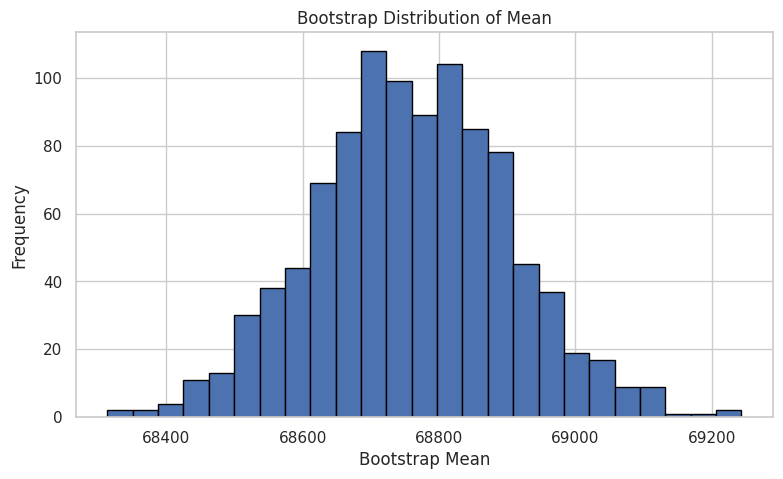

In [28]:
plt.figure(figsize=(9, 5))

plt.hist(
    bootstrap_means,
    bins=25,
    edgecolor="black"
)

plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Mean")

plt.show()

### Interpretasi

Bootstrap mean sebesar 68,760.38 sangat dekat dengan population mean.
Distribusi bootstrap juga membentuk pola yang cukup simetris di sekitar
nilai tersebut, sehingga estimasi mean terlihat stabil.

## 9. Confidence Interval

Confidence interval digunakan untuk memberikan rentang nilai yang
diperkirakan mencakup parameter population. Pada bagian ini digunakan
bootstrap distribution untuk membentuk interval kepercayaan 95%.

In [29]:
lower_ci = np.percentile(bootstrap_means, 2.5)
upper_ci = np.percentile(bootstrap_means, 97.5)

print(f"95% Confidence Interval: {lower_ci:,.2f} - {upper_ci:,.2f}")

95% Confidence Interval: 68,489.16 - 69,046.07


### Interpretasi

Confidence interval 95% berada pada rentang 68,489.16 hingga 69,046.07.
Rentang ini menunjukkan perkiraan nilai mean population berdasarkan
hasil bootstrap.

## 10. Normal Distribution

Normal distribution merupakan distribusi berbentuk simetris seperti
lonceng. Distribusi ini sering digunakan sebagai dasar dalam berbagai
metode statistik.

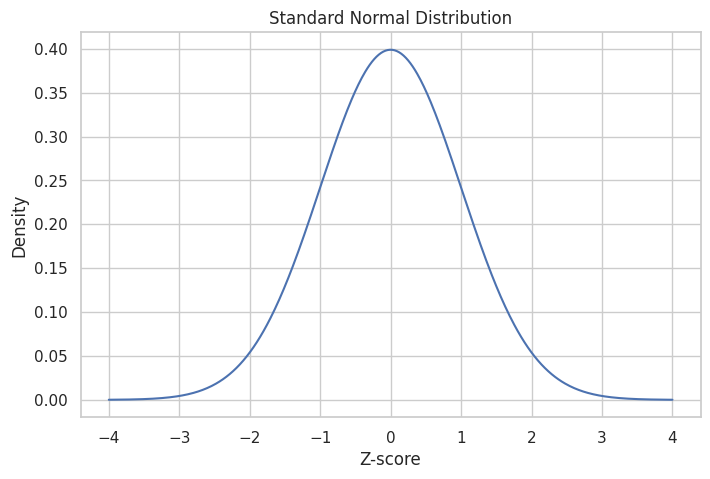

In [30]:
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x, loc=0, scale=1)

plt.figure(figsize=(8, 5))

plt.plot(x, y)

plt.xlabel("Z-score")
plt.ylabel("Density")
plt.title("Standard Normal Distribution")

plt.show()

### Interpretasi

Grafik menunjukkan bentuk distribusi normal yang simetris dan
berpusat di sekitar Z-score 0. Nilai yang semakin jauh dari pusat
memiliki density yang semakin kecil.

## 11. Long-Tailed Distribution dan t-Distribution

Long-tailed distribution memiliki ekor yang lebih panjang dibandingkan
normal distribution, sehingga peluang munculnya nilai ekstrem lebih besar.

t-distribution memiliki bentuk mirip normal distribution, tetapi ekornya
lebih tebal dan sering digunakan ketika ukuran sample relatif kecil.

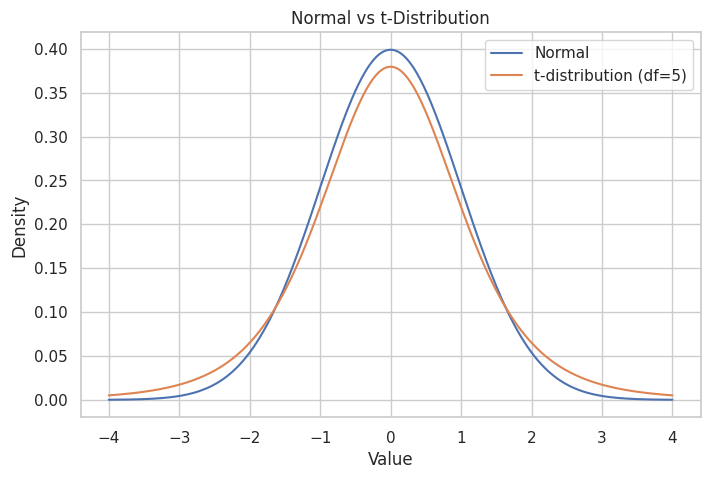

In [31]:
x = np.linspace(-4, 4, 500)

normal = stats.norm.pdf(x)
t_dist = stats.t.pdf(x, df=5)

plt.figure(figsize=(8, 5))

plt.plot(x, normal, label="Normal")
plt.plot(x, t_dist, label="t-distribution (df=5)")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Normal vs t-Distribution")
plt.legend()

plt.show()

### Interpretasi

Grafik menunjukkan bahwa t-distribution memiliki puncak sedikit lebih
rendah dan ekor lebih tebal dibandingkan normal distribution.
Artinya, t-distribution memberi peluang lebih besar pada nilai yang
berada jauh dari pusat.

## 12. Binomial Distribution

Binomial distribution digunakan untuk menghitung kemungkinan jumlah
keberhasilan dari sejumlah percobaan yang hanya memiliki dua hasil,
seperti berhasil atau gagal.

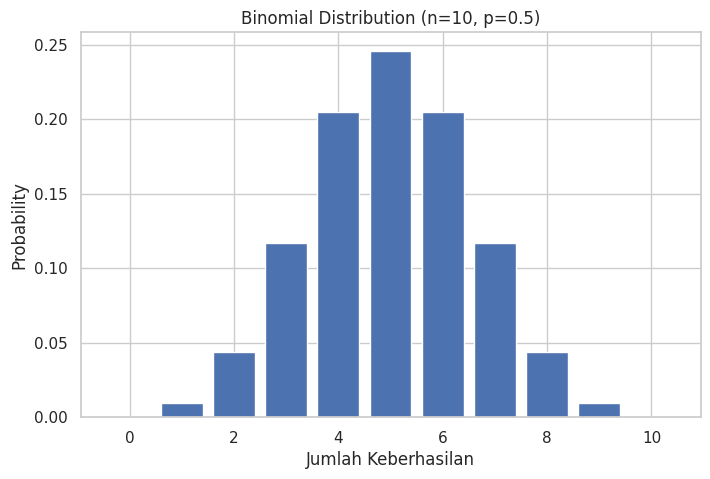

In [32]:
n = 10
p = 0.5

x = np.arange(0, n + 1)
binomial_prob = stats.binom.pmf(x, n, p)

plt.figure(figsize=(8, 5))

plt.bar(x, binomial_prob)

plt.xlabel("Jumlah Keberhasilan")
plt.ylabel("Probability")
plt.title("Binomial Distribution (n=10, p=0.5)")

plt.show()

### Interpretasi

Distribusi binomial terlihat simetris karena peluang keberhasilan
ditetapkan sebesar 0.5. Probabilitas terbesar berada di sekitar
5 keberhasilan dari 10 percobaan.

## 13. Poisson Distribution

Poisson distribution digunakan untuk memodelkan jumlah kejadian
yang terjadi dalam suatu interval waktu atau ruang tertentu,
dengan rata-rata kejadian yang dianggap tetap.

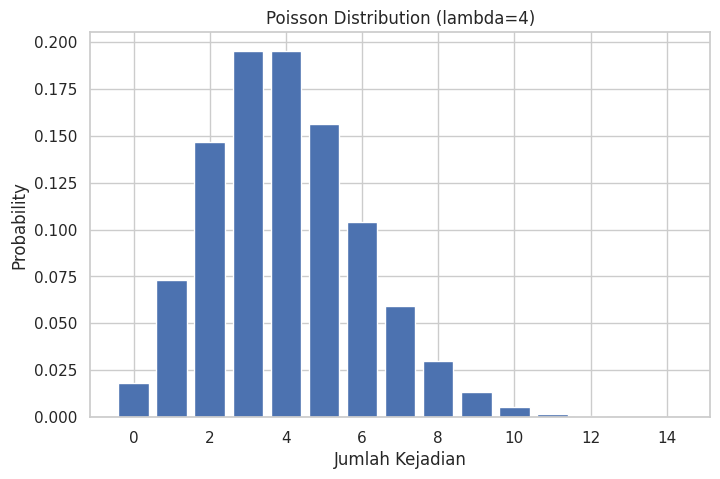

In [33]:
lam = 4

x = np.arange(0, 15)
poisson_prob = stats.poisson.pmf(x, mu=lam)

plt.figure(figsize=(8, 5))

plt.bar(x, poisson_prob)

plt.xlabel("Jumlah Kejadian")
plt.ylabel("Probability")
plt.title("Poisson Distribution (lambda=4)")

plt.show()

### Interpretasi

Distribusi Poisson dengan λ = 4 memiliki probabilitas tertinggi
di sekitar 3–4 kejadian. Semakin jauh dari nilai tersebut,
probabilitas kejadian semakin kecil.

## 14. Ringkasan Chapter 2

Pada chapter ini telah dipelajari konsep population dan sample,
random sampling, sampling distribution, standard error, bootstrap,
confidence interval, serta beberapa distribusi probabilitas.

Ukuran sample memengaruhi kestabilan estimasi, sedangkan bootstrap
dapat digunakan untuk memperkirakan variasi statistik melalui
resampling.

## 15. Kesimpulan

Sampling memungkinkan kita memperoleh informasi mengenai population
tanpa menggunakan seluruh data. Hasil dari sample dapat berbeda-beda,
sehingga konsep sampling distribution dan standard error digunakan
untuk memahami variasi tersebut.

Bootstrap dan confidence interval membantu mengukur ketidakpastian
estimasi, sedangkan distribusi seperti normal, t, binomial, dan
Poisson digunakan untuk memodelkan berbagai karakteristik data.

## Referensi

Bruce, P., Bruce, A., & Gedeck, P. (2020).
*Practical Statistics for Data Scientists: 50+ Essential Concepts
Using R and Python*. 2nd Edition. O'Reilly Media.

Repository kode dan dataset:
https://github.com/gedeck/practical-statistics-for-data-scientists